# Part 2: Feature Engineering & Exploratory Data Analysis (EDA)
This notebook engineers numerical metrics out of string components and visualizes key analytical trends within the content distribution.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# sns.set_style("whitegrid")
# plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv(r"C:\Users\shubh\OneDrive\Documents\netflix advanced project\netflix _new_project\data\netflix_cleaned.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,movie_duration,seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,90.0,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September,NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September,NaN,1.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September,NaN,2.0


# Split duration into numeric value and unit

In [ ]:
df["duration_num"] = df["duration"].astype(str).str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].astype(str).str.extract(r"([A-Za-z]+)")

# Fill missing duration numbers with median
df["duration_num"] = df["duration_num"].fillna(df["duration_num"].median())



NameError: name 'df' is not defined

# Create binary features

In [ ]:
df["is_movie"] = (df["type"].str.lower() == "movie").astype(int)
df["is_tv_show"] = (df["type"].str.lower() == "tv show").astype(int)

In [ ]:
# Create metadata counts
df["genre_count"] = df["listed_in"].fillna("").apply(lambda x: len([i.strip() for i in x.split(",") if i.strip() != ""]))#counts how many genres a title belongs to
df["cast_count"] = df["cast"].fillna("").apply(lambda x: len([i.strip() for i in x.split(",") if i.strip() != ""]))#counts how many actors are listed.
df["country_count"] = df["country"].fillna("").apply(lambda x: len([i.strip() for i in x.split(",") if i.strip() != ""]))#how many countries worked together to make the movie or TV show.

# Primary groupings
df["primary_country"] = df["country"].fillna("").apply(lambda x: x.split(",")[0].strip() if x else "Unknown")#assign one main country to each title, making grouping and plotting easier.
df["primary_genre"] = df["listed_in"].fillna("").apply(lambda x: x.split(",")[0].strip() if x else "Unknown")#main genre of the title

# Title length features
df["title_length"] = df["title"].fillna("").apply(len)
df["title_word_count"] = df["title"].fillna("").apply(lambda x: len(x.split()))
                                       

# content type distribution

In [ ]:

plt.figure(figsize=(8, 5))
type_counts=df["type"].value_counts().reset_index() 
Fig=px.bar(type_counts,x="type",y="count",title="Content Type Distribution",
           text="count",color="type")
Fig.update_layout(template="plotly_dark",xaxis_title="Type Of Content",yaxis_title="Number Of Titles")
Fig.show()
Fig.write_image("..\plots\content_type_distribution.png")

<Figure size 800x500 with 0 Axes>

# Content Added Over Years

In [ ]:


added_trends=df["year_added"].value_counts().reset_index()
Fig=px.line(added_trends,x="year_added",y="count",title="Content Added Over Years",
          markers=True)
Fig.update_layout(template="plotly_dark",xaxis_title="Year",yaxis_title="Number Of Titles")
Fig.show()
Fig.write_image("..\plots\content_added_over_years.png")

# Top Countries

In [ ]:
top_countries = df["primary_country"].value_counts().reset_index().head(10)
Fig=px.bar(top_countries,x="count",y="primary_country",title="Top 10 Countries by Content Count",color="primary_country")
Fig.update_layout(template="plotly_dark",xaxis_title="Number Of Titles",yaxis_title="Country",showlegend=False)
Fig.show()
Fig.write_image(r"C:\Users\shubh\OneDrive\Documents\netflix advanced project\plots\top_countries.png")


# Top 10 Genres

In [ ]:


genre_series = df["listed_in"].dropna().str.split(",").explode().str.strip() #explode create separate row for each genre
top_genres = genre_series.value_counts().reset_index().head(10)
fig=px.bar(top_genres,x="count",y="listed_in",title="Top 10 Genres",color="listed_in")
fig.update_layout(xaxis_title="Number Of Titles",yaxis_title="Genre",template="plotly_dark",showlegend=False)
fig.show()
fig.write_image(r"C:\Users\shubh\OneDrive\Documents\netflix advanced project\plots\top10_genres.png")

# Movie Duration Distribution

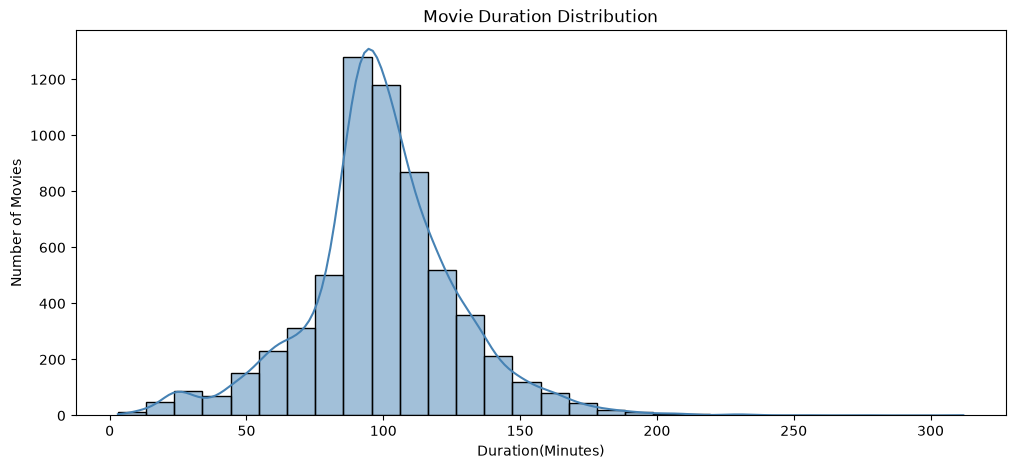

In [ ]:
# Duration analyses
movie_df = df[df["duration_unit"].str.contains("min", case=False, na=False)].copy()#case=False → Ignores uppercase/lowercase (min, MIN, Min all match).
# na),=False → If a value is missing NaN treat it as False instead of causing an error.
plt.figure(figsize=(12, 5))
sns.histplot(movie_df["duration_num"], bins=30, kde=True, color="steelblue")
plt.title("Movie Duration Distribution")
plt.xlabel("Duration(Minutes)")
plt.ylabel("Number of Movies")
plt.savefig(r"C:\Users\shubh\OneDrive\Documents\netflix advanced project\plots\movie_duration_distribution.png",bbox_inches="tight",dpi=300)
plt.show()

# TV Show Season Distribution

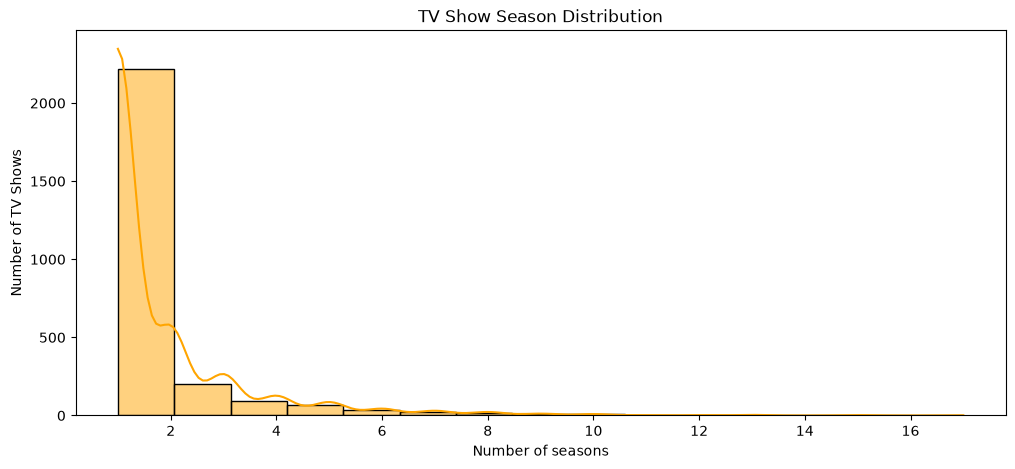

In [ ]:
show_df = df[df["duration_unit"].str.contains("Season", case=False, na=False)].copy()
plt.figure(figsize=(12, 5))
sns.histplot(show_df["duration_num"], bins=15, kde=True, color="orange")
plt.title("TV Show Season Distribution")
plt.xlabel("Number of seasons")
plt.ylabel("Number of TV Shows")
plt.savefig(r"C:\Users\shubh\OneDrive\Documents\netflix advanced project\plots\tv_show_season_distribution.png",dpi=300,bbox_inches="tight")
plt.show()

In [22]:
df.to_csv("netflix_featured.csv", index=False)